In [247]:
import pandas as pd
df=pd.read_csv('train.csv')

DATA CLEANING

In [248]:
CGECK THE NUMER OF MISISNG VALUES IN EACH COLUMN

SyntaxError: invalid syntax (1851228255.py, line 1)

In [249]:
df.isnull().sum()     

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [250]:
PERCENTAGE OF MISISNG VALUES IN EACH COLUMN

SyntaxError: invalid syntax (2474998516.py, line 1)

In [251]:
df.isnull().sum()/len(df)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

cabin has msot misisng values almost 77 percent o we have to drop it

In [252]:
df.drop['cabin']

TypeError: 'method' object is not subscriptable

In [253]:
df=df.drop("Cabin",axis=1)

In [254]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Now time to build a pipelien end to end wiht Simpleimputer labelencoder onehop encoding

In [255]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [256]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


seeing idnexe of each columnm

In [257]:
df.columns.tolist()

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Creatng Transformers

In [258]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder

In [259]:
Now createng anotehr transforemr for habdling categroical values

SyntaxError: invalid syntax (3096368481.py, line 1)

In [260]:
trf1=ColumnTransformer([
('impute_age',SimpleImputer(strategy="median"),[2]),
('imputer_fare',SimpleImputer(strategy="median"),[5]),
('impute_embarked',SimpleImputer(strategy="most_frequent"),[6])
],remainder="passthrough")

In [261]:
trf2 = ColumnTransformer([
    ('encode_sex',      OneHotEncoder(sparse_output=False), [4]),
    ('encode_embarked', OneHotEncoder(sparse_output=False), [2])
], remainder='passthrough')

In [262]:
y=df["Survived"]
X=df.drop("Survived",axis=1)


In [263]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

NOR CREATING A PIPELINE

MOST IMPORTANT DOUBT WHY DO WE NEED PIPELINE AND HOW IT AVOIDS DATA LEAKAGE
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline.fit(X_train, y_train)
# internally it ALWAYS does:
# 1. scale X_train only
# 2. fit model
# CANNOT mess up order! ✅

In [264]:
pipeline=Pipeline(
    [
        ("trf1",trf1),
        ("trf2",trf2),
        ("model",DecisionTreeClassifier())
    ]
)

In [265]:
pipeline.fit(X_train,y_train)
prediction=pipeline.predict(X_test)
print(prediction)

[0 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1
 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 1 1 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 0 1 0 1
 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1]


In [266]:
print(trf2)

ColumnTransformer(remainder='passthrough',
                  transformers=[('encode_sex',
                                 OneHotEncoder(sparse_output=False), [4]),
                                ('encode_embarked',
                                 OneHotEncoder(sparse_output=False), [2])])


In [268]:
import numpy as np

# Input: [Pclass, Sex, Age, SibSp, Parch, Fare, Embarked]
test_input = np.array([[3, 'male', 22.0, 1, 0, 7.25, 'S']])

prediction = pipeline.predict(test_input)

if prediction[0] == 1:
    print("Survived!")
else:
    print("Did not survive!")

Did not survive!


/home/owais/Desktop/reducdemo/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/home/owais/Desktop/reducdemo/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/home/owais/Desktop/reducdemo/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [269]:
print("Accuracy:", pipeline.score(X_test, y_test))

Accuracy: 0.7821229050279329


In [270]:
from sklearn import set_config
set_config(display='diagram')

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('trf1', ...), ('trf2', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Sex','Age',...,'Parch','Fare','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_age', ...), ('imputer_fare', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all rema

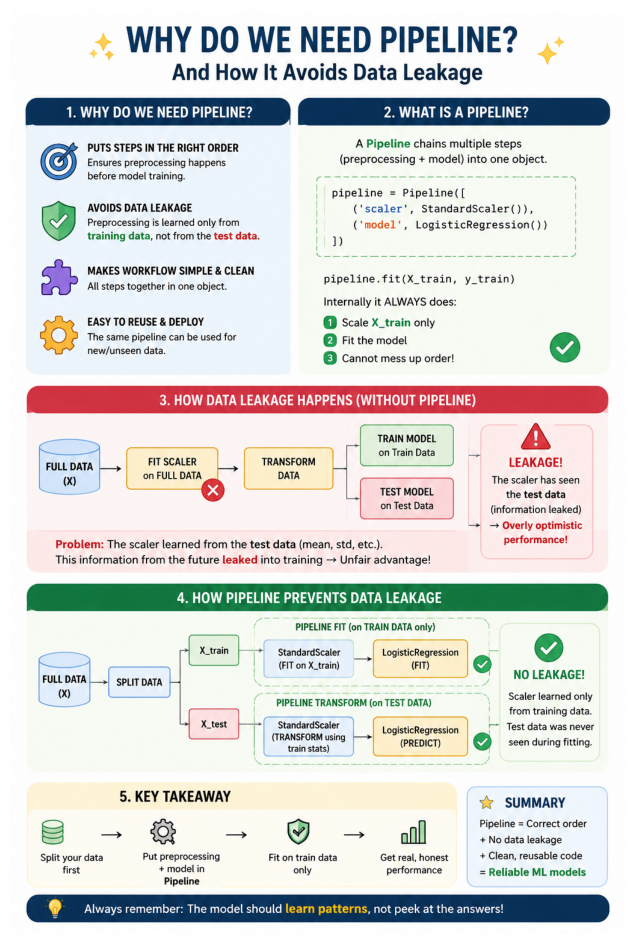

In [272]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("pipelineimp1.png")

# Increase figure size
plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from IPython.display import Image, display

display(Image(filename="pipelineimp2.png"))